In [2]:
library(tidyverse)
library(tidymodels)
library(vip)
library(patchwork) # For combining plots


Attaching package: ‘vip’


The following object is masked from ‘package:utils’:

    vi




,skim_type,skim_variable,n_missing,complete_rate,factor.ordered,factor.n_unique,factor.top_counts,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<lgl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,factor,Species,0,1,FALSE,3,"set: 50, ver: 50, vir: 50",NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,Sepal.Length,0,1,NA,NA,NA,5.843333,0.8280661,4.3,5.1,5.80,6.4,7.9,▆▇▇▅▂
3,numeric,Sepal.Width,0,1,NA,NA,NA,3.057333,0.4358663,2.0,2.8,3.00,3.3,4.4,▁▆▇▂▁
4,numeric,Petal.Length,0,1,NA,NA,NA,3.758000,1.7652982,1.0,1.6,4.35,5.1,6.9,▇▁▆▇▂
5,numeric,Petal.Width,0,1,NA,NA,NA,1.199333,0.7622377,0.1,0.3,1.30,1.8,2.5,▇▁▇▅▃


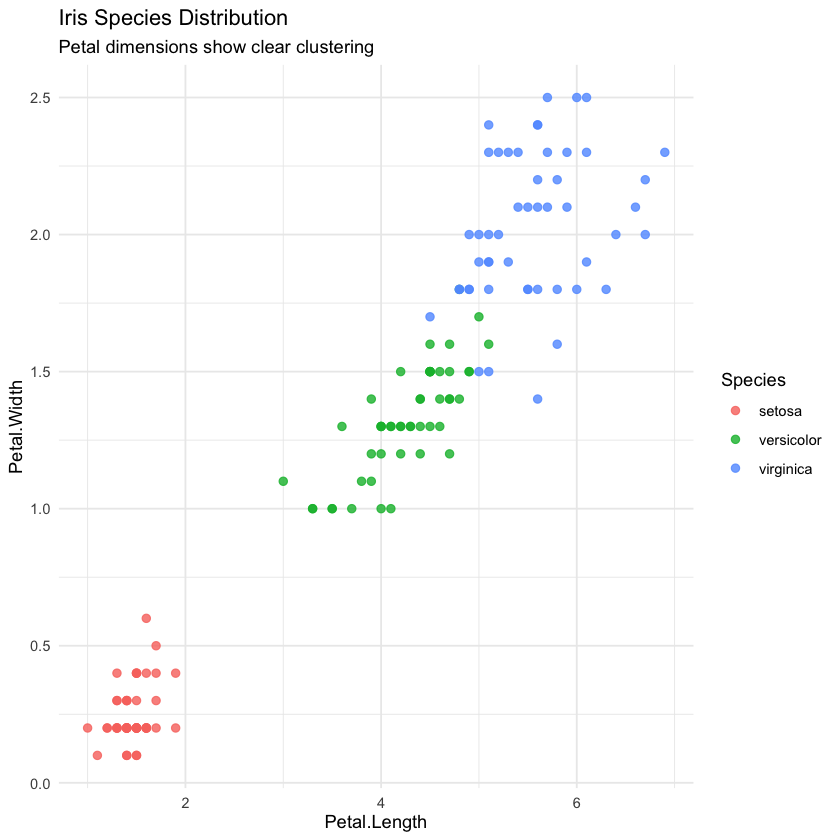

In [3]:
# Summarize the data
iris %>% skimr::skim()

# Quick Visualization of the classes
ggplot(iris, aes(Petal.Length, Petal.Width, color = Species)) +
  geom_point(alpha = 0.8, size = 2) +
  theme_minimal() +
  labs(title = "Iris Species Distribution", subtitle = "Petal dimensions show clear clustering")

In [4]:
set.seed(123) # For reproducibility
iris_split <- initial_split(iris, prop = 0.8, strata = Species)
train_data <- training(iris_split)
test_data  <- testing(iris_split)

# Recipe: Normalize all numeric predictors
iris_recipe <- recipe(Species ~ ., data = train_data) %>%
  step_normalize(all_numeric_predictors()) %>%
  prep()

In [5]:
rf_spec <- rand_forest(trees = 500, mtry = 2) %>%
  set_engine("ranger", importance = "permutation") %>%
  set_mode("classification")

# Fit the model
rf_fit <- rf_spec %>%
  fit(Species ~ ., data = bake(iris_recipe, new_data = NULL))

print(rf_fit)

parsnip model object

Ranger result

Call:
 ranger::ranger(x = maybe_data_frame(x), y = y, mtry = min_cols(~2,      x), num.trees = ~500, importance = ~"permutation", num.threads = 1,      verbose = FALSE, seed = sample.int(10^5, 1), probability = TRUE) 

Type:                             Probability estimation 
Number of trees:                  500 
Sample size:                      120 
Number of independent variables:  4 
Mtry:                             2 
Target node size:                 10 
Variable importance mode:         permutation 
Splitrule:                        gini 
OOB prediction error (Brier s.):  0.03101748 


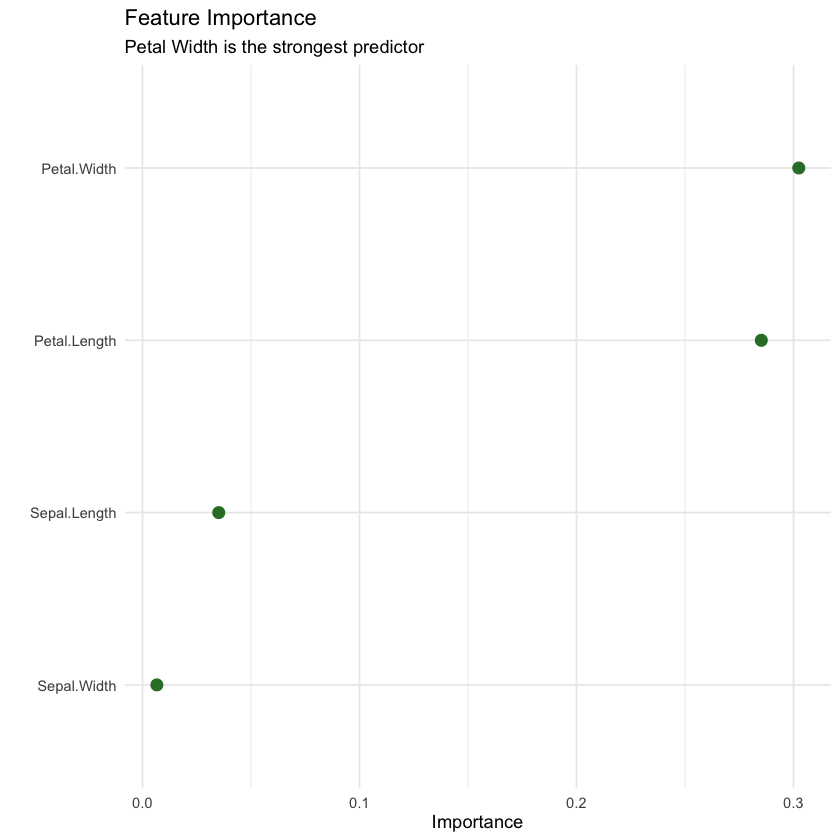

In [6]:
vip_plot <- vip(rf_fit, geom = "point", aesthetics = list(color = "#2E7D32", size = 3)) +
  theme_minimal() +
  labs(title = "Feature Importance", subtitle = "Petal Width is the strongest predictor")

print(vip_plot)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


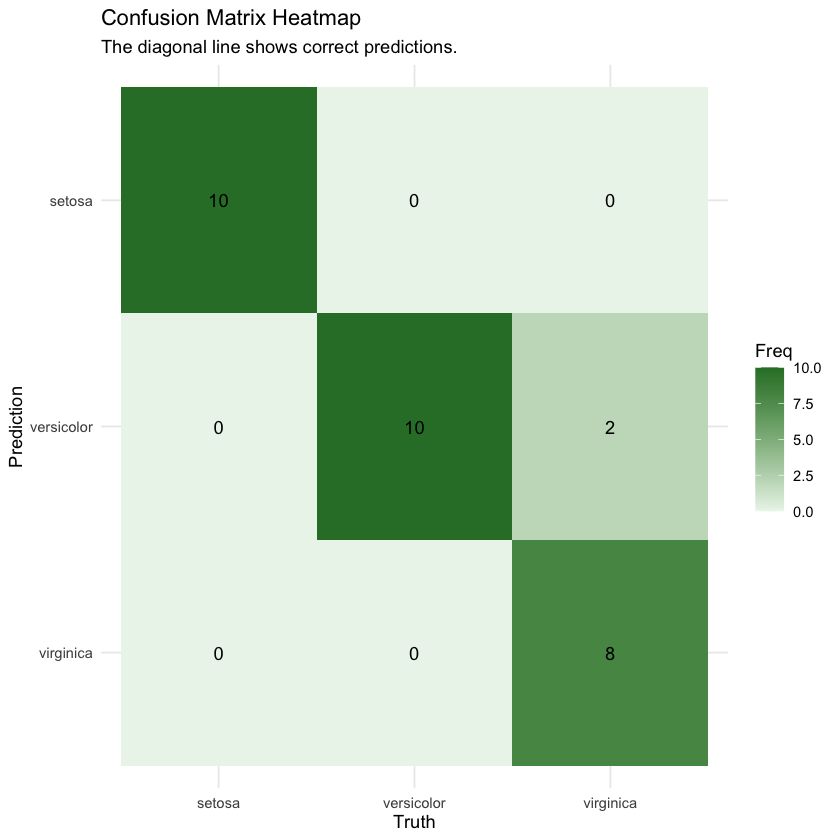

In [12]:
# Heatmap Confusion Matrix
results %>%
  conf_mat(truth = Species, estimate = .pred_class) %>%
  autoplot(type = "heatmap") +
  scale_fill_gradient(low = "#ebf5eb", high = "#2e7d32") +
  theme_minimal() +
  labs(title = "Confusion Matrix Heatmap", 
       subtitle = "The diagonal line shows correct predictions.")

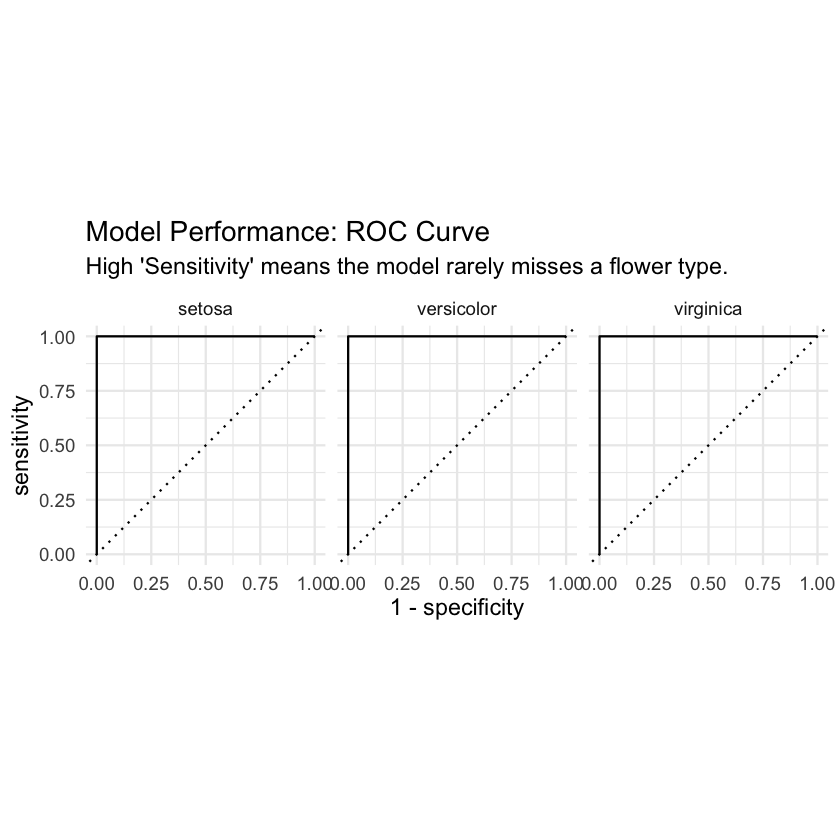

In [10]:
# Professional ROC Plot
results %>%
  roc_curve(truth = Species, .pred_setosa, .pred_versicolor, .pred_virginica) %>%
  autoplot() +
  theme_minimal(base_size = 14) +
  scale_color_viridis_d(option = "magma", end = 0.8) +
  labs(title = "Model Performance: ROC Curve", 
       subtitle = "High 'Sensitivity' means the model rarely misses a flower type.")

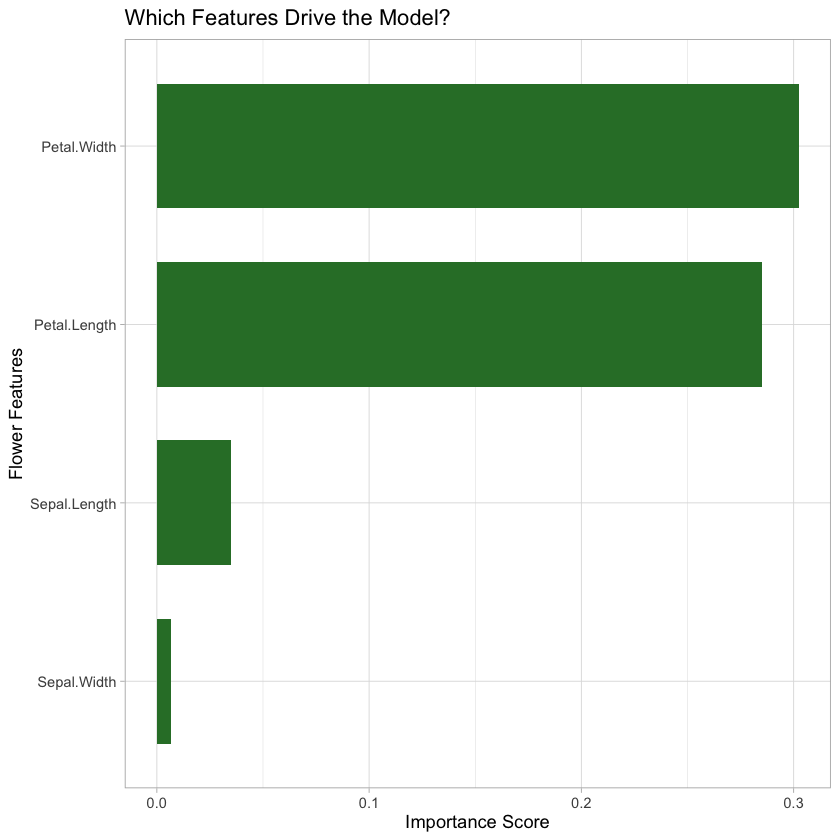

In [11]:
# Better Variable Importance
vip(rf_fit, geom = "col", aesthetics = list(fill = "#2E7D32", width = 0.7)) +
  theme_light() +
  labs(title = "Which Features Drive the Model?",
       x = "Flower Features", 
       y = "Importance Score")

In [9]:
final_metrics <- results %>%
  metrics(truth = Species, estimate = .pred_class)

print(final_metrics)

# A tibble: 2 × 3
  .metric  .estimator .estimate
  <chr>    <chr>          <dbl>
1 accuracy multiclass     0.933
2 kap      multiclass     0.9  


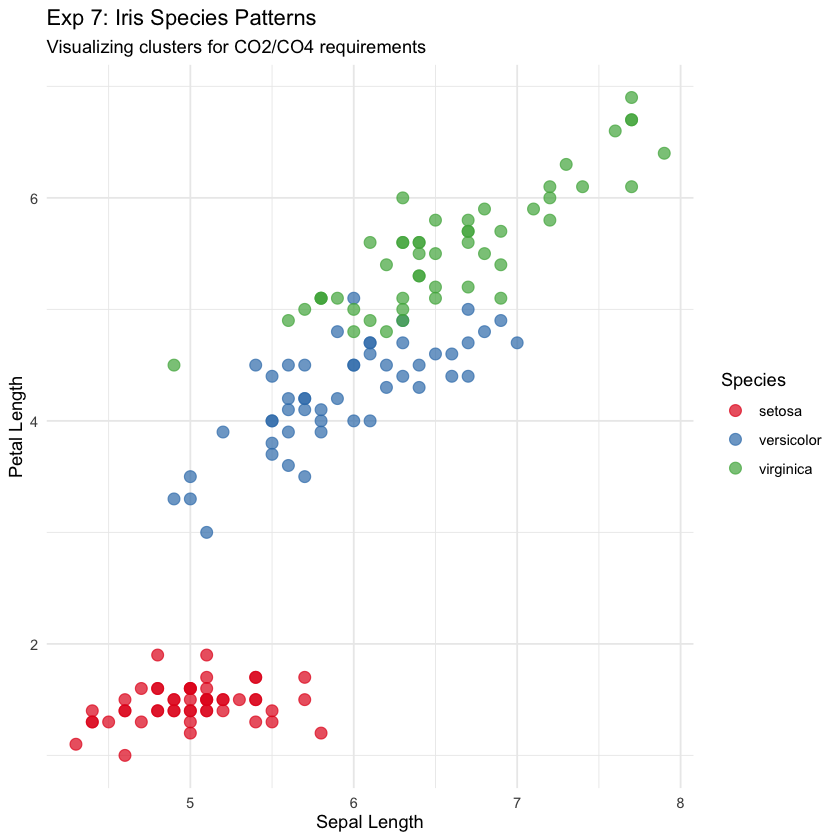

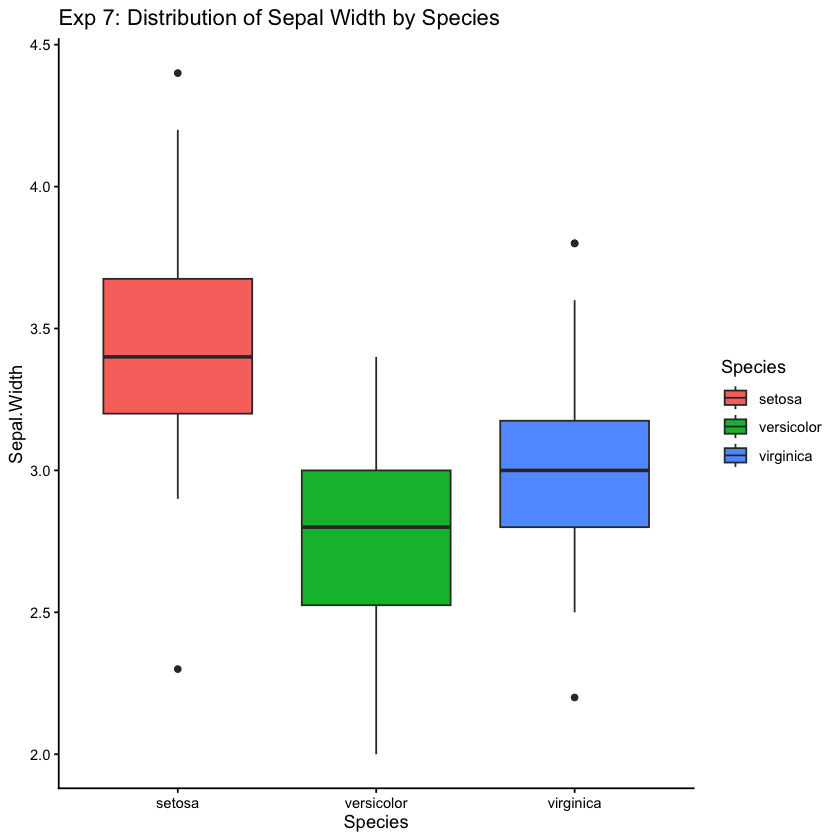

In [7]:
# 1. Load the standard visualization library (usually pre-installed)
library(ggplot2)

# 2. Use the iris dataset directly
data(iris)

# 3. Create a Multi-variable Scatter Plot
# This visualizes Sepal Length vs Petal Length, grouped by Species
ggplot(iris, aes(x = Sepal.Length, y = Petal.Length, color = Species)) +
  geom_point(size = 3, alpha = 0.7) +
  theme_minimal() +
  labs(title = "Exp 7: Iris Species Patterns",
       subtitle = "Visualizing clusters for CO2/CO4 requirements",
       x = "Sepal Length",
       y = "Petal Length") +
  scale_color_brewer(palette = "Set1")

# 4. Create a Boxplot to see distribution (Univariate analysis)
# This meets the requirement for "elaborating datasets using statistical summaries" 
ggplot(iris, aes(x = Species, y = Sepal.Width, fill = Species)) +
  geom_boxplot() +
  theme_classic() +
  labs(title = "Exp 7: Distribution of Sepal Width by Species")

[1] "--- Regression Model Summary ---"



Call:
lm(formula = Petal.Length ~ Petal.Width, data = train_set)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.34299 -0.29932 -0.01289  0.21392  1.39796 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.06470    0.08205   12.98   <2e-16 ***
Petal.Width  2.24096    0.05813   38.55   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4858 on 118 degrees of freedom
Multiple R-squared:  0.9264,	Adjusted R-squared:  0.9258 
F-statistic:  1486 on 1 and 118 DF,  p-value: < 2.2e-16



Root Mean Square Error (RMSE): 0.4477541

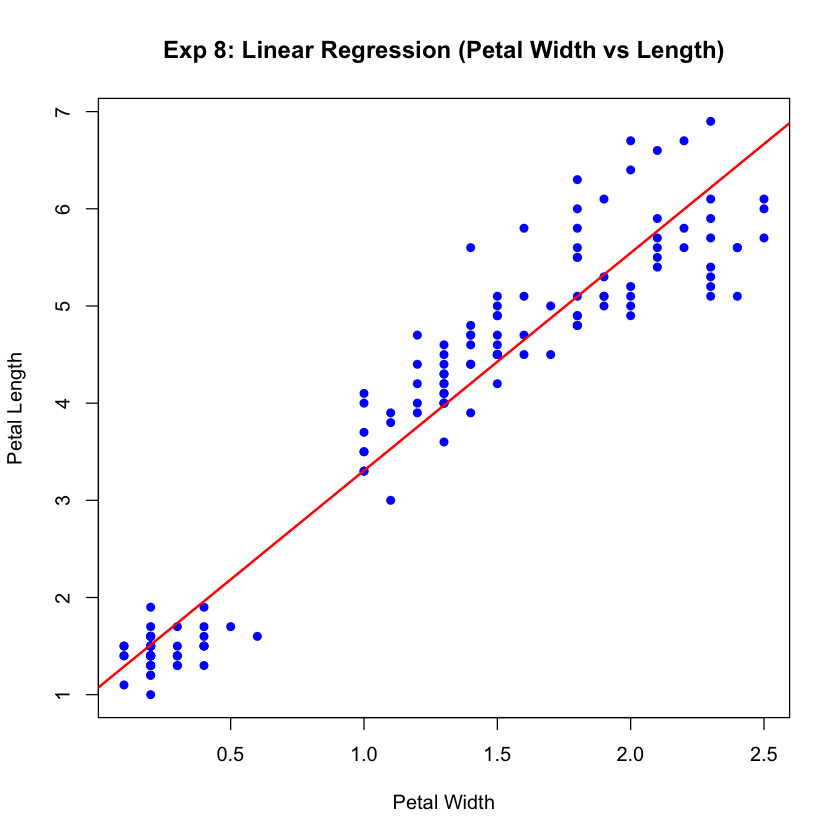

In [6]:
# 1. Load the dataset
data(iris)

# 2. Split the data (80% Training, 20% Testing) 
# Goal: Predict Petal.Length based on Petal.Width
set.seed(42) # Ensuring reproducibility
sample_indices <- sample(1:nrow(iris), 0.8 * nrow(iris))
train_set <- iris[sample_indices, ]
test_set <- iris[-sample_indices, ]

# 3. Build the Linear Regression Model
# Formula: Petal.Length = Intercept + (Slope * Petal.Width)
reg_model <- lm(Petal.Length ~ Petal.Width, data = train_set)

# 4. Output Model Summary (Coefficients, R-squared, P-values)
print("--- Regression Model Summary ---")
summary(reg_model)

# 5. Predict on Test Data and Evaluate Performance
predictions <- predict(reg_model, newdata = test_set)

# Calculate Evaluation Metrics (RMSE)
rmse <- sqrt(mean((test_set$Petal.Length - predictions)^2))
cat("\nRoot Mean Square Error (RMSE):", rmse)

# 6. Visualize the Regression Line
plot(iris$Petal.Width, iris$Petal.Length, 
     main="Exp 8: Linear Regression (Petal Width vs Length)",
     xlab="Petal Width", ylab="Petal Length", col="blue", pch=16)
abline(reg_model, col="red", lwd=2)

[1] "--- K-Means Clustering Results ---"
  Sepal.Length Sepal.Width Petal.Length Petal.Width
1     6.850000    3.073684     5.742105    2.071053
2     5.006000    3.428000     1.462000    0.246000
3     5.901613    2.748387     4.393548    1.433871
   
    setosa versicolor virginica
  1      0          2        36
  2     50          0         0
  3      0         48        14


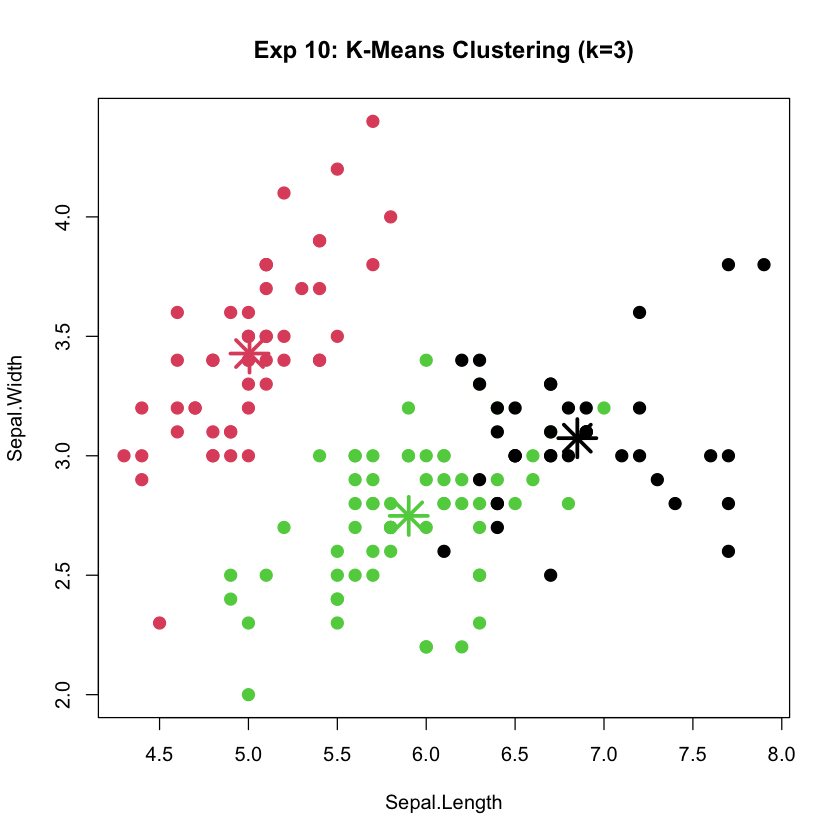

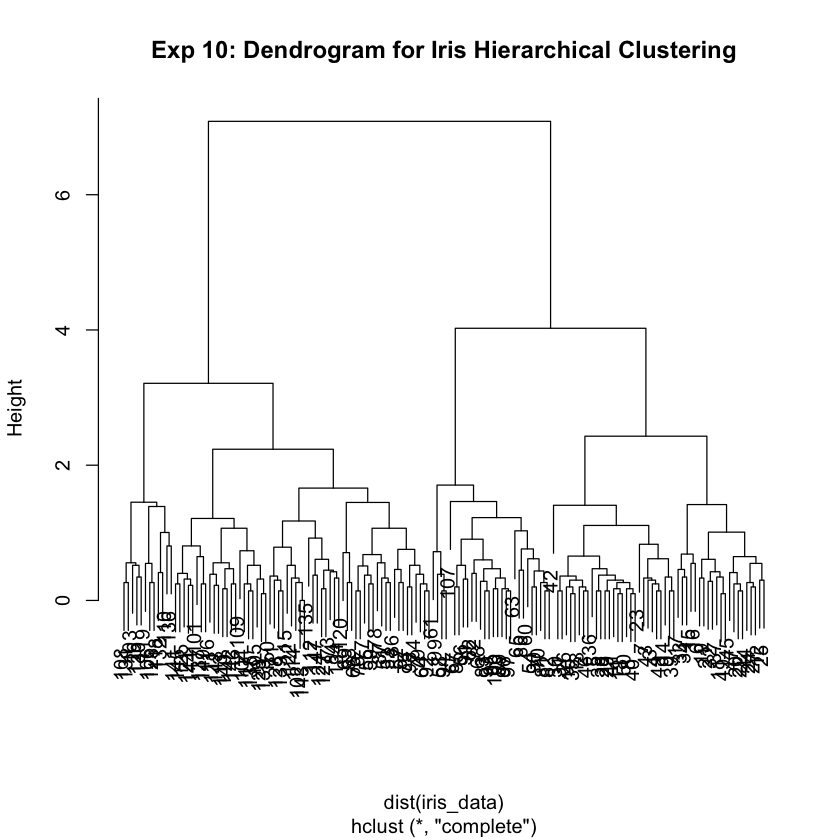

In [5]:
# 1. Load the dataset
data(iris)

# 2. Prepare Data: Clustering only uses numeric features (Columns 1 to 4)
# We drop the 'Species' label to perform Unsupervised Learning
iris_data <- iris[, 1:4]

# 3. Apply K-Means Clustering
set.seed(2026) # For reproducibility
# k = 3 clusters; nstart = 20 attempts to find the best initial centroids
kmeans_result <- kmeans(iris_data, centers = 3, nstart = 20)

# 4. View Cluster Summary for Lab Record
print("--- K-Means Clustering Results ---")
print(kmeans_result$centers) # Coordinates of the cluster centers
print(table(kmeans_result$cluster, iris$Species)) # Comparison with actual labels

# 5. Visualize the Clusters
# Using standard R plot to avoid package installation issues
plot(iris_data[c("Sepal.Length", "Sepal.Width")], 
     col = kmeans_result$cluster, 
     main = "Exp 10: K-Means Clustering (k=3)",
     pch = 20, cex = 2)

# Mark the Cluster Centers
points(kmeans_result$centers[, c("Sepal.Length", "Sepal.Width")], 
       col = 1:3, pch = 8, cex = 3, lwd = 3)

# 6. (Optional) Hierarchical Clustering - Another technique mentioned in syllabus
clusters_h <- hclust(dist(iris_data))
plot(clusters_h, main = "Exp 10: Dendrogram for Iris Hierarchical Clustering")